In [1]:
#importing libraries
from sklearn.utils import resample
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import train_test_split



In [2]:
#Reading csv into dataframe
df=pd.read_csv(r"C:\Users\ddnri\OneDrive\creditcard.csv")
#Printing data frame
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [3]:
#shows class imbalance
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [4]:
#Handling imbalanced data, Making dataset balanced
x=df.drop('Class',axis=1)
y=df['Class']
sm=SMOTE()
x_res,y_res=sm.fit_resample(x,y)
df1=pd.DataFrame(x_res,columns=x.columns)
df1['Class']=y_res
print(pd.Series(df1['Class']).value_counts())

Class
0    284315
1    284315
Name: count, dtype: int64


In [5]:
#checking null values in each column
df1.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [6]:
#Removing Duplicate rows
df1.drop_duplicates(inplace=True)
#Printing column names
df1.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [7]:
#Performing Standardisation 
ss=StandardScaler()
df1['Time']=ss.fit_transform(df1[['Time']])
df1['Amount']=ss.fit_transform(df1[['Amount']])
df1

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.812634,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.240913,0
1,-1.812634,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.422823,0
2,-1.812614,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.275570,0
3,-1.812614,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.122919,0
4,-1.812593,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.118805,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568625,-1.457670,1.092228,0.900139,0.382818,3.164703,0.184730,-0.221693,-0.020081,-0.014653,0.860946,...,-0.426558,-0.810219,0.072510,0.148298,0.357440,-0.118157,0.012340,0.054086,-0.417854,1
568626,-0.290206,-2.321623,1.531959,-0.986283,1.909335,-1.270249,-0.845193,-2.507086,1.120803,-1.360772,...,0.663998,0.454896,-0.413867,0.103114,-0.068347,-0.380902,0.464025,0.280491,-0.247194,1
568627,-1.652502,-0.154138,2.739165,-4.823695,3.645434,-1.884058,-2.372435,-3.741634,1.137613,-0.556001,...,0.532593,-0.210913,0.422773,0.136681,-1.179321,0.320415,0.474495,0.130620,-0.430458,1
568628,1.206144,-0.052178,4.228929,-6.526216,7.263436,0.508830,-2.631289,-1.865171,0.773262,-3.851612,...,0.415307,-0.468787,0.005745,-0.384663,-0.478188,0.462406,0.567676,0.264533,-0.431467,1


In [8]:
#Handling Outliers using z-score method
for col in df.columns:
    mu=df[col].mean()
    sig=df[col].std()
    df1['z-score']=(df1[col]-mu)/sig
    df1[(df1['z-score']>-3)&(df1['z-score']<3)]
df1

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,z-score
0,-1.812634,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.240913,0,-0.041599
1,-1.812634,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.422823,0,-0.041599
2,-1.812614,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.275570,0,-0.041599
3,-1.812614,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.122919,0,-0.041599
4,-1.812593,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.118805,0,-0.041599
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568625,-1.457670,1.092228,0.900139,0.382818,3.164703,0.184730,-0.221693,-0.020081,-0.014653,0.860946,...,-0.810219,0.072510,0.148298,0.357440,-0.118157,0.012340,0.054086,-0.417854,1,24.039010
568626,-0.290206,-2.321623,1.531959,-0.986283,1.909335,-1.270249,-0.845193,-2.507086,1.120803,-1.360772,...,0.454896,-0.413867,0.103114,-0.068347,-0.380902,0.464025,0.280491,-0.247194,1,24.039010
568627,-1.652502,-0.154138,2.739165,-4.823695,3.645434,-1.884058,-2.372435,-3.741634,1.137613,-0.556001,...,-0.210913,0.422773,0.136681,-1.179321,0.320415,0.474495,0.130620,-0.430458,1,24.039010
568628,1.206144,-0.052178,4.228929,-6.526216,7.263436,0.508830,-2.631289,-1.865171,0.773262,-3.851612,...,-0.468787,0.005745,-0.384663,-0.478188,0.462406,0.567676,0.264533,-0.431467,1,24.039010


In [9]:
#Handling Outliers using iqr method
for col1 in df.columns:
    q1=df[col1].quantile(0.25)
    q3=df[col1].quantile(0.75)
    iqr=q3-q1
    upp=q3+1.5*iqr
    low=q1-1.5*iqr
    df[(df[col1]>=low)&(df[col1]<=upp)]
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


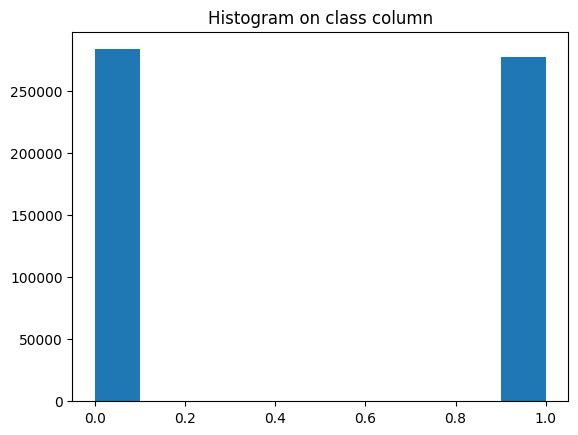

In [10]:
#Ploting a histogram on class column
plt.hist(df1['Class'])
plt.title("Histogram on class column")
plt.show()

In [11]:
#Feature Selection

In [12]:
x = df1.drop(columns=['Class','z-score'])
y = df1['Class']

In [13]:
y

0         0
1         0
2         0
3         0
4         0
         ..
568625    1
568626    1
568627    1
568628    1
568629    1
Name: Class, Length: 560172, dtype: int64

In [14]:
x_sample, _, y_sample, _ = train_test_split(
    x, y,
    train_size=10000,
    random_state=42,
    stratify=y          # <-- this makes it stratified
)
y_sample=y_sample.astype(int)

# Verify class balance is preserved
print(y_sample.value_counts())

Class
0    5057
1    4943
Name: count, dtype: int64


In [15]:
model = LogisticRegression(max_iter=1000, solver='saga', n_jobs=-1, random_state=42)


In [16]:
fs_seq = SequentialFeatureSelector(
    estimator=model,
    n_features_to_select=15,
    direction='forward',
    scoring='roc_auc',
    cv=2,
    n_jobs=-1
)

In [17]:
fs_seq.fit(x_sample, y_sample)

SequentialFeatureSelector(cv=2,
                          estimator=LogisticRegression(max_iter=1000, n_jobs=-1,
                                                       random_state=42,
                                                       solver='saga'),
                          n_features_to_select=15, n_jobs=-1,
                          scoring='roc_auc')

In [18]:
sfs_features = x.columns[fs_seq.get_support()].tolist()


In [19]:
print(sfs_features)

['Time', 'V3', 'V4', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V14', 'V16', 'V17', 'V19', 'V22']


In [20]:
#correlation matrix
df_selected=df1[sfs_features]
plt.figure(figsize=(12,10))
correlation_matrix=df_selected.corr()
print(correlation_matrix)

          Time        V3        V4        V6        V7        V8        V9  \
Time  1.000000  0.175482 -0.226457  0.140560  0.251123 -0.209397  0.183255   
V3    0.175482  1.000000 -0.778356  0.535139  0.893603 -0.346814  0.758501   
V4   -0.226457 -0.778356  1.000000 -0.488207 -0.737191  0.180169 -0.795372   
V6    0.140560  0.535139 -0.488207  1.000000  0.394035 -0.544092  0.414703   
V7    0.251123  0.893603 -0.737191  0.394035  1.000000 -0.121957  0.785954   
V8   -0.209397 -0.346814  0.180169 -0.544092 -0.121957  1.000000 -0.136764   
V9    0.183255  0.758501 -0.795372  0.414703  0.785954 -0.136764  1.000000   
V10   0.243811  0.846122 -0.819585  0.480557  0.876638 -0.152184  0.853929   
V11  -0.333698 -0.731576  0.819458 -0.546009 -0.672646  0.260709 -0.724819   
V12   0.282708  0.766627 -0.853530  0.540666  0.748621 -0.235804  0.783392   
V14   0.189868  0.673351 -0.820465  0.587960  0.575608 -0.286240  0.711616   
V16   0.261117  0.741643 -0.759653  0.496661  0.775156 -0.292371

<Figure size 1200x1000 with 0 Axes>

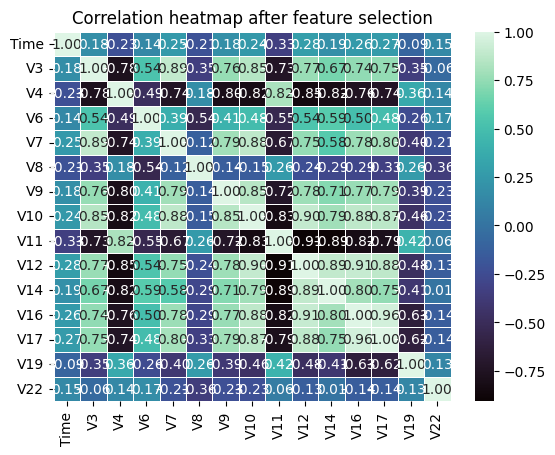

In [21]:
#heatmap
sns.heatmap(correlation_matrix,annot=True,cmap='mako',fmt=".2f",linewidths=0.5)
plt.title("Correlation heatmap after feature selection")
plt.show()

In [22]:
#logistic regression

In [44]:
#importing libraries
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,mean_squared_error, mean_absolute_error,accuracy_score,precision_score,f1_score, recall_score,r2_score
from sklearn.metrics import roc_auc_score,roc_curve,auc
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

In [24]:
logreg = LogisticRegression()

In [25]:
X = df1[sfs_features]
y = df1['Class']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [28]:
# Hyperparameter grid
param_grid = {
    'C': [0.1, 1, 10],
    'penalty': ['l2'],   # safe option
    'solver': ['lbfgs']  # stable + fast
}

In [29]:
# Grid Search
grid = GridSearchCV(logreg, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid.fit(X_train_scaled, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}


In [30]:
X_train, X_test, y_train, y_test

(            Time         V3         V4        V6         V7         V8  \
 500596  1.684674  -4.248948   1.156468 -0.968397  -1.635539   0.508804   
 365767 -1.369983 -24.268916  11.803155 -2.590652 -17.710618   2.320237   
 490384  0.296649 -25.612106  11.312501  5.612562 -39.278025 -36.577825   
 172899  0.692177  -0.749556  -1.073929  0.214317  -1.087857   0.172542   
 322711  0.676214  -4.526820   2.508140 -0.742227  -2.386493  -1.064983   
 ...          ...        ...        ...       ...        ...        ...   
 110703 -0.327021  -0.426582  -0.404109 -0.737552   0.341009  -0.307407   
 260136  1.479622  -0.605170  -0.788264 -0.203064   0.861209   0.067349   
 369180 -0.959909 -12.989883   8.759796 -2.773680 -14.179543   8.038312   
 132427 -0.160858  -0.721776   0.071903  3.635628  -0.821682   0.929256   
 122429 -0.231590   1.326391  -1.345201 -0.683284   0.856022  -0.178265   
 
                V9        V10       V11        V12        V14        V16  \
 500596  -0.998791  -3

In [31]:
logreg.fit(X_train, y_train)

LogisticRegression()

In [32]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test_scaled)

In [33]:
y_pred

array([1, 0, 0, ..., 0, 1, 0], shape=(112035,))

In [34]:
accuracy_score(y_test, y_pred) 
# The ratio of correct predictions out of the total predictions made by the model.


0.9773106618467443

In [35]:
precision_score(y_test, y_pred)
# The ratio of correctly predicted positive values out of all values predicted 

np.float64(0.9888516454008408)

In [36]:
recall_score(y_test, y_pred)
# The ratio of correctly predicted positive values out of all actual positive values.

np.float64(0.9649420821511827)

In [37]:
f1_score(y_test, y_pred)


np.float64(0.97675056705934)

In [38]:
print(confusion_matrix(y_test, y_pred))

[[56096   602]
 [ 1940 53397]]


In [39]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     56698
           1       0.99      0.96      0.98     55337

    accuracy                           0.98    112035
   macro avg       0.98      0.98      0.98    112035
weighted avg       0.98      0.98      0.98    112035



In [40]:
print("logistic regression ROC-AUC:", roc_auc_score(y_test, y_pred)) #roc-auc score

logistic regression ROC-AUC: 0.9771622118399922


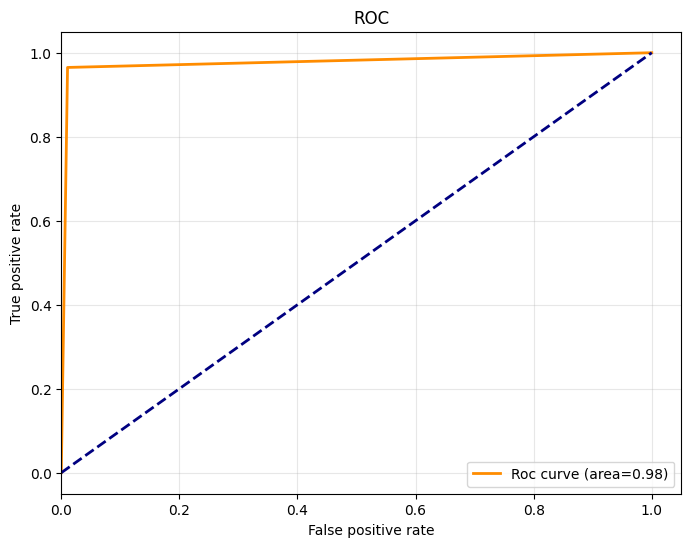

In [45]:
fpr,tpr,thresholds=roc_curve(y_test,y_pred)
roc_auc=auc(fpr,tpr)
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color='darkorange',lw=2,label=f'Roc curve (area={roc_auc:.2f})')
plt.plot([0,1],[0,1],color='navy',lw=2,linestyle='--')
plt.xlim([0.0,1.05])
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [46]:
#K-Nearest Neighbour

In [47]:
#Importing libraries
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,classification_report
from sklearn .model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler


In [48]:
X = df1[sfs_features]
y = df1['Class']

In [49]:
X,y

(            Time         V3        V4        V6         V7        V8  \
 0      -1.812634   2.536347  1.378155  0.462388   0.239599  0.098698   
 1      -1.812634   0.166480  0.448154 -0.082361  -0.078803  0.085102   
 2      -1.812614   1.773209  0.379780  1.800499   0.791461  0.247676   
 3      -1.812614   1.792993 -0.863291  1.247203   0.237609  0.377436   
 4      -1.812593   1.548718  0.403034  0.095921   0.592941 -0.270533   
 ...          ...        ...       ...       ...        ...       ...   
 568625 -1.457670   0.382818  3.164703 -0.221693  -0.020081 -0.014653   
 568626 -0.290206  -0.986283  1.909335 -0.845193  -2.507086  1.120803   
 568627 -1.652502  -4.823695  3.645434 -2.372435  -3.741634  1.137613   
 568628  1.206144  -6.526216  7.263436 -2.631289  -1.865171  0.773262   
 568629 -0.959585 -13.635869  8.696481 -2.818157 -14.349107  8.450223   
 
               V9        V10       V11        V12        V14        V16  \
 0       0.363787   0.090794 -0.551600  -0.6178

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [51]:
#feature scaling


In [52]:
scaler = StandardScaler()

In [53]:
X_train = scaler.fit_transform(X_train)   
X_test = scaler.transform(X_test)         

In [54]:
#Hyper parameter tuning

In [55]:
param_grid = {
    'n_neighbors': [5, 15,25,35,50],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

In [56]:
X_small, _, y_small, _ = train_test_split(X_train, y_train,
                                           train_size=0.01,
                                           random_state=42)

grid = RandomizedSearchCV(KNeighborsClassifier(), param_grid,
                          n_iter=3, cv=2,
                          scoring='roc_auc', n_jobs=-1)
grid.fit(X_small, y_small)
print("Best params:", grid.best_params_)

Best params: {'weights': 'uniform', 'n_neighbors': 25, 'metric': 'manhattan'}


In [57]:
#Hyperparameter tuning result=50

In [58]:
knn = KNeighborsClassifier(n_neighbors=50)

In [59]:
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=50)

In [60]:
y_pred = knn.predict(X_test)

In [61]:
y_test

549042    1
36816     0
129109    0
221776    0
264270    0
         ..
222969    0
175355    0
81499     0
560098    1
45711     0
Name: Class, Length: 112035, dtype: int64

In [62]:
y_pred


array([1, 0, 0, ..., 0, 1, 0], shape=(112035,))

In [63]:
accuracy_score(y_test, y_pred) # The ratio of correct predictions out of the total predictions made by the model.


0.995662069888874

In [64]:
precision_score(y_test, y_pred) # The ratio of correctly predicted positive values out of all values predicted 

np.float64(0.9912939111119072)

In [65]:
recall_score(y_test, y_pred) # The ratio of correctly predicted positive values out of all actual positive values.

np.float64(1.0)

In [66]:
f1_score(y_test, y_pred)

np.float64(0.995627923713566)

In [67]:
print(confusion_matrix(y_test, y_pred))

[[56212   486]
 [    0 55337]]


In [68]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56698
           1       0.99      1.00      1.00     55337

    accuracy                           1.00    112035
   macro avg       1.00      1.00      1.00    112035
weighted avg       1.00      1.00      1.00    112035



In [69]:
print("KNN ROC-AUC:", roc_auc_score(y_test, y_pred)) #roc-auc-score

KNN ROC-AUC: 0.9957141345373735


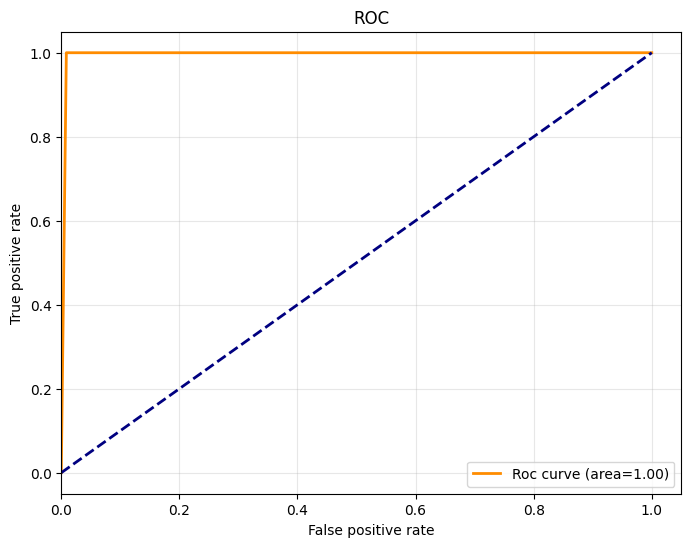

In [70]:
fpr,tpr,thresholds=roc_curve(y_test,y_pred)
roc_auc=auc(fpr,tpr)
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color='darkorange',lw=2,label=f'Roc curve (area={roc_auc:.2f})')
plt.plot([0,1],[0,1],color='navy',lw=2,linestyle='--')
plt.xlim([0.0,1.05])
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [71]:
#Support Vector Machine

In [72]:
#Importing libraries
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,classification_report
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

In [73]:
X = df1[sfs_features]
y = df1['Class']

In [74]:
X,y

(            Time         V3        V4        V6         V7        V8  \
 0      -1.812634   2.536347  1.378155  0.462388   0.239599  0.098698   
 1      -1.812634   0.166480  0.448154 -0.082361  -0.078803  0.085102   
 2      -1.812614   1.773209  0.379780  1.800499   0.791461  0.247676   
 3      -1.812614   1.792993 -0.863291  1.247203   0.237609  0.377436   
 4      -1.812593   1.548718  0.403034  0.095921   0.592941 -0.270533   
 ...          ...        ...       ...       ...        ...       ...   
 568625 -1.457670   0.382818  3.164703 -0.221693  -0.020081 -0.014653   
 568626 -0.290206  -0.986283  1.909335 -0.845193  -2.507086  1.120803   
 568627 -1.652502  -4.823695  3.645434 -2.372435  -3.741634  1.137613   
 568628  1.206144  -6.526216  7.263436 -2.631289  -1.865171  0.773262   
 568629 -0.959585 -13.635869  8.696481 -2.818157 -14.349107  8.450223   
 
               V9        V10       V11        V12        V14        V16  \
 0       0.363787   0.090794 -0.551600  -0.6178

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [76]:
#Feature scaling

In [77]:
scaler = StandardScaler()


In [78]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [79]:
#Hyperparameter tuning

In [80]:
kernels = ['linear', 'rbf', 'poly']

print("Kernel Comparison:")
for k in kernels:
    model = SVC(kernel=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    print(f"Kernel: {k}, MSE: {mse}")

Kernel Comparison:
Kernel: linear, MSE: 0.022957111616905432
Kernel: rbf, MSE: 0.01139822376935779
Kernel: poly, MSE: 0.013201231757932788


In [81]:
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly']
    
}

In [82]:
grid = GridSearchCV(SVC(), param_grid, cv=2, scoring='accuracy', n_jobs=-1)

In [83]:
X_svm, _, y_svm, _ = train_test_split(
    X_train, y_train,
    train_size=0.02,
    random_state=42
)

In [84]:
grid.fit(X_svm, y_svm)

GridSearchCV(cv=2, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10],
                         'kernel': ['linear', 'rbf', 'poly']},
             scoring='accuracy')

In [85]:
print("Best Params:", grid.best_params_)

Best Params: {'C': 10, 'kernel': 'rbf'}


In [86]:
best_model=grid.best_estimator_

In [87]:
y_pred = best_model.predict(X_test)


In [88]:
y_test

549042    1
36816     0
129109    0
221776    0
264270    0
         ..
222969    0
175355    0
81499     0
560098    1
45711     0
Name: Class, Length: 112035, dtype: int64

In [89]:
y_pred

array([1, 0, 0, ..., 0, 1, 0], shape=(112035,))

In [90]:
accuracy_score(y_test, y_pred) # The ratio of correct predictions out of the total predictions made by the model.


0.985549158745035

In [91]:
precision_score(y_test, y_pred)
# The ratio of correctly predicted positive values out of all values predicted 

np.float64(0.9940949227373068)

In [92]:
recall_score(y_test, y_pred) # The ratio of correctly predicted positive values out of all actual positive values.

np.float64(0.9765437230063068)

In [93]:
f1_score(y_test, y_pred)

np.float64(0.9852411642980209)

In [94]:
print(confusion_matrix(y_test, y_pred))

[[56377   321]
 [ 1298 54039]]


In [95]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99     56698
           1       0.99      0.98      0.99     55337

    accuracy                           0.99    112035
   macro avg       0.99      0.99      0.99    112035
weighted avg       0.99      0.99      0.99    112035



In [96]:
print("SVM ROC-AUC:", roc_auc_score(y_test, y_pred)) #roc-auc-score

SVM ROC-AUC: 0.9854410738210482


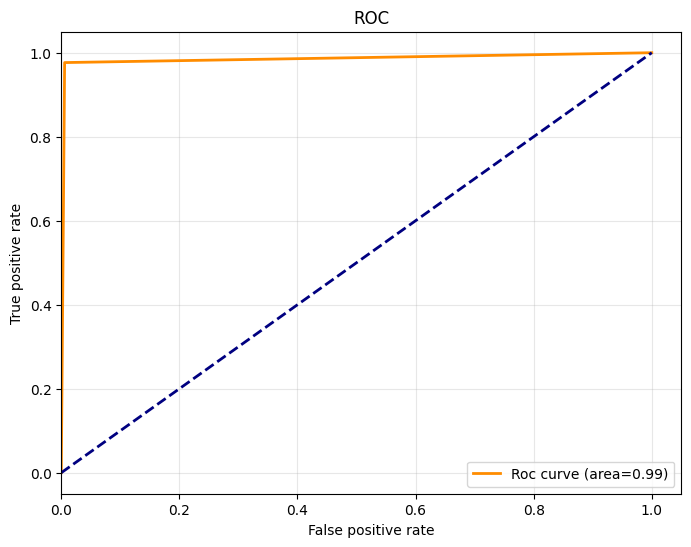

In [97]:
fpr,tpr,thresholds=roc_curve(y_test,y_pred)
roc_auc=auc(fpr,tpr)
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color='darkorange',lw=2,label=f'Roc curve (area={roc_auc:.2f})')
plt.plot([0,1],[0,1],color='navy',lw=2,linestyle='--')
plt.xlim([0.0,1.05])
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [98]:
#XGBoost

In [99]:
#importing libraries
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,classification_report

In [100]:
X = df1[sfs_features]   # selected features
y = df1['Class']        # target

In [101]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [102]:
 #Feature Scaling 

In [103]:
scaler = StandardScaler()

In [104]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [105]:
# Handling Imbalance 

In [106]:
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

In [107]:
#Model

In [108]:
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False
)

In [109]:
#Hyperparameter tuning

In [110]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}


In [111]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=10,      # keep small for speed
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

In [112]:
random_search.fit(X_train_scaled, y_train)

print("Best Params:", random_search.best_params_)


Fitting 3 folds for each of 10 candidates, totalling 30 fits


C:\Users\ddnri\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:54:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.2, 'colsample_bytree': 1.0}


In [113]:
best_model = random_search.best_estimator_

In [114]:
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]


In [115]:
y_pred

array([1, 0, 0, ..., 0, 1, 0], shape=(112035,))

In [116]:
y_prob

array([9.9999952e-01, 1.1921217e-09, 1.2211212e-06, ..., 2.2829956e-06,
       9.9999928e-01, 3.6211884e-06], shape=(112035,), dtype=float32)

In [117]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9998036327933235


In [118]:
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 0.999985592497222


In [119]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56698
           1       1.00      1.00      1.00     55337

    accuracy                           1.00    112035
   macro avg       1.00      1.00      1.00    112035
weighted avg       1.00      1.00      1.00    112035



In [120]:
print("Precision:", precision_score(y_test, y_pred))

Precision: 0.9996025939774924


In [121]:
print("Recall:", recall_score(y_test, y_pred))

Recall: 1.0


In [122]:
print("F1 Score:", f1_score(y_test, y_pred))

F1 Score: 0.9998012574980126


In [123]:
print(confusion_matrix(y_test, y_pred))

[[56676    22]
 [    0 55337]]


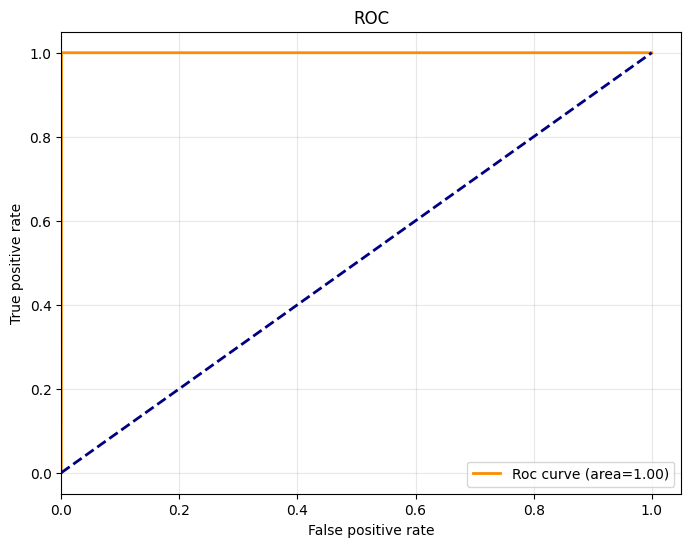

In [124]:
fpr,tpr,thresholds=roc_curve(y_test,y_pred)
roc_auc=auc(fpr,tpr)
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color='darkorange',lw=2,label=f'Roc curve (area={roc_auc:.2f})')
plt.plot([0,1],[0,1],color='navy',lw=2,linestyle='--')
plt.xlim([0.0,1.05])
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [125]:
#Random Forest

In [126]:
#importing libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,confusion_matrix,
    f1_score, roc_auc_score, classification_report, roc_curve, auc
)
from sklearn.preprocessing import StandardScaler



In [127]:
X = df1[sfs_features] 
y = df1['Class']        

In [128]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [129]:
#Feature Scaling

In [130]:
scaler = StandardScaler()

In [131]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [132]:
#Model

In [133]:
rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)


In [134]:
#Hyperparameter Tuning

In [135]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}


In [136]:
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=2,              
    scoring='f1',           
    n_jobs=-1,
    verbose=2,
    random_state=42
)


In [137]:
random_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 2 candidates, totalling 10 fits


RandomizedSearchCV(estimator=RandomForestClassifier(class_weight='balanced',
                                                    n_jobs=-1,
                                                    random_state=42),
                   n_iter=2, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='f1', verbose=2)

In [138]:
print("Best Params:", random_search.best_params_)

Best Params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}


In [139]:
best_model = random_search.best_estimator_

In [140]:
y_pred = best_model.predict(X_test_scaled)

In [141]:
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

In [142]:
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(112035,))

In [143]:
y_prob

array([0.   , 0.   , 0.01 , ..., 0.045, 0.025, 0.   ], shape=(112035,))

In [144]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9998839648324185


In [145]:
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


ROC-AUC: 0.9999883308966662


In [146]:
print("Precision:", precision_score(y_test, y_pred))

Precision: 0.9998375128635649


In [147]:
print("Recall:", recall_score(y_test, y_pred))

Recall: 0.9999277769752998


In [148]:
print("F1 Score:", f1_score(y_test, y_pred))

F1 Score: 0.9998826428822908


In [149]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       1.00      1.00      1.00     55384

    accuracy                           1.00    112035
   macro avg       1.00      1.00      1.00    112035
weighted avg       1.00      1.00      1.00    112035



In [150]:
print(confusion_matrix(y_test, y_pred))

[[56642     9]
 [    4 55380]]


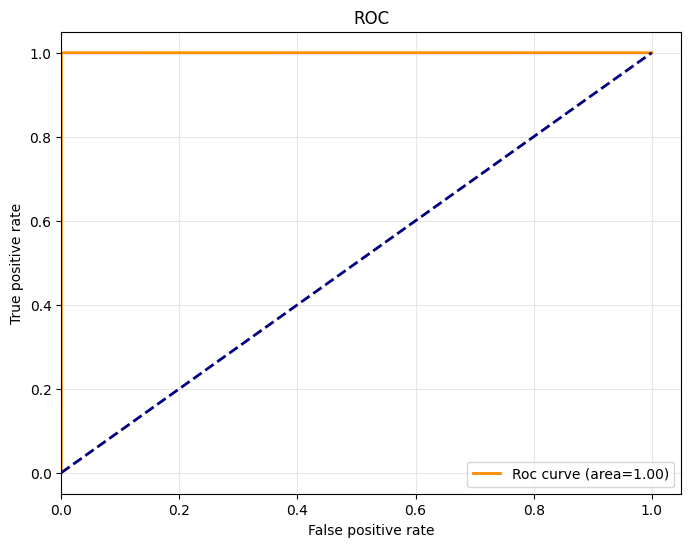

In [151]:
fpr,tpr,thresholds=roc_curve(y_test,y_pred)
roc_auc=auc(fpr,tpr)
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color='darkorange',lw=2,label=f'Roc curve (area={roc_auc:.2f})')
plt.plot([0,1],[0,1],color='navy',lw=2,linestyle='--')
plt.xlim([0.0,1.05])
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

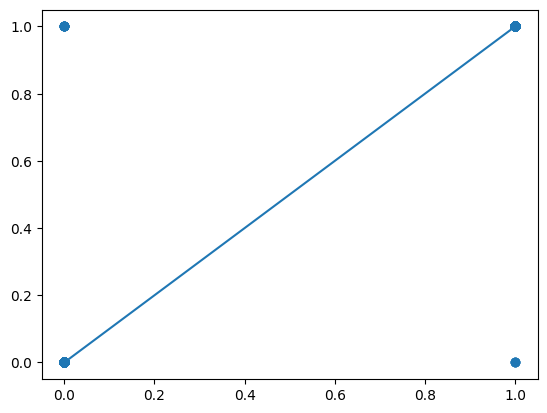

In [152]:
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)])


In [153]:
#Creating pickle file
import pickle

# create model
model = KNeighborsClassifier(n_neighbors=50)

# train it
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [154]:
with open("KNN_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved as KNN_model.pkl")

Model saved as KNN_model.pkl
